# 2 - Results

Every number here is produced by this repository and averaged over 3 seeds:

| File | Produced by |
|---|---|
| `results/reproduced_metrics.csv` | `scripts/sweep.py` — the personalisation curve |
| `results/balance_comparison.csv` | none / SMOTE / cGAN, after personalisation |
| `results/global_model_comparison.csv` | the same, for the global model alone |
| `results/aami_metrics.json` | per-class Se / +P / specificity |
| `results/cgan_training_loss.csv` | 20,000 steps of GAN loss |

Model selection and the balancing study are written up in `docs/experiments.md`.

In [1]:
import json
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ecg.config import CLASSES

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
curve = pd.read_csv("../results/reproduced_metrics.csv")
curve

,augmentation,extra_features,train_minutes,test_from_minute,seeds,accuracy,accuracy_std,macro_f1,macro_f1_std,cohen_kappa,f1_F,f1_N,f1_S,f1_V
0,none,none,1,5,3,0.9641,0.0012,0.6863,0.0067,0.8214,0.089,0.982,0.761,0.914
1,none,none,2,5,3,0.9704,0.0010,0.8098,0.0112,0.8542,0.542,0.986,0.792,0.919
2,none,none,3,5,3,0.9728,0.0025,0.8394,0.0152,0.8670,0.632,0.986,0.803,0.936
3,none,none,4,5,3,0.9755,0.0026,0.8490,0.0156,0.8798,0.651,0.987,0.812,0.946
4,none,none,5,5,3,0.9777,0.0014,0.8571,0.0085,0.8892,0.672,0.989,0.814,0.954


## How much of the patient's own data is needed?

Each row personalises the global model on the first *n* minutes of a DS2
patient's own record, then scores minutes 5-30. Predictions are pooled across
all 22 patients into a single confusion matrix.

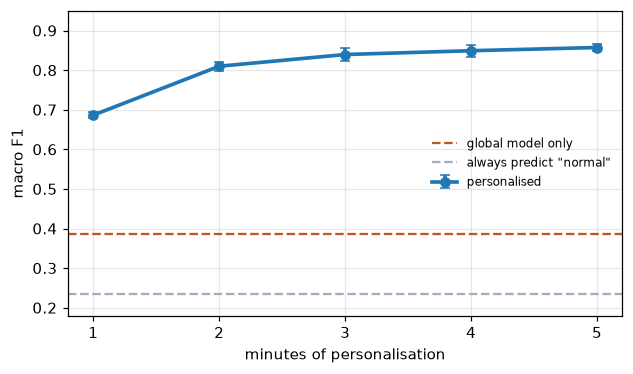

In [2]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.errorbar(curve.train_minutes, curve.macro_f1, yerr=curve.macro_f1_std,
            marker="o", lw=2.4, capsize=3, label="personalised")
ax.axhline(0.387, color="#c05621", ls="--", lw=1.5, label="global model only")
ax.axhline(0.235, color="#a0aec0", ls="--", lw=1.5, label='always predict "normal"')
ax.set(xlabel="minutes of personalisation", ylabel="macro F1",
       xticks=[1, 2, 3, 4, 5], ylim=(0.18, 0.95))
ax.legend(frameon=False, fontsize=8)

## Per-class performance

Reported in the AAMI convention so it can be compared against published work.
S and F are the hard classes: S differs from N mainly in timing rather than
shape, and F is by definition intermediate between N and V.

In [3]:
aami = json.load(open("../results/aami_metrics.json"))
pd.DataFrame({
    c: {"beats": v["support"],
        "Se": round(v["sensitivity"][0], 3),
        "+P": round(v["ppv"][0], 3),
        "Spec": round(v["specificity"][0], 3),
        "F1": round(v["f1"][0], 3)}
    for c, v in aami["per_class"].items()
}).T

,beats,Se,+P,Spec,F1
F,286.0,0.776,0.593,0.996,0.672
N,36566.0,0.990,0.987,0.898,0.989
S,1590.0,0.747,0.895,0.996,0.814
V,2674.0,0.966,0.942,0.996,0.954


## Balancing: none vs SMOTE vs cGAN

DS1 is 90% class N. Two rebalancing strategies are implemented: SMOTE, and a
conditional GAN that generates beats of a requested class.

The comparison is shown at both stages, because they disagree.

In [4]:
balance = pd.read_csv("../results/balance_comparison.csv")
glob = pd.read_csv("../results/global_model_comparison.csv")
(glob[["balance", "macro_f1"]].rename(columns={"macro_f1": "global only"})
 .merge(balance[["balance", "macro_f1", "macro_f1_std", "f1_F", "f1_S", "f1_V"]]
        .rename(columns={"macro_f1": "personalised"}), on="balance")
 .set_index("balance"))

,global only,personalised,macro_f1_std,f1_F,f1_S,f1_V
balance,,,,,,
none,0.3874,0.8571,0.0085,0.672,0.814,0.954
smote,0.3638,0.8132,0.0121,0.553,0.785,0.931
cgan,0.4087,0.8541,0.0169,0.655,0.824,0.949


The cGAN beats SMOTE at both stages, and is the only strategy that improves the
global model. Neither improves the personalised result — fine-tuning on a
patient's own data already adapts to their class mix, so global rebalancing
corrects a problem the next stage was going to correct anyway.

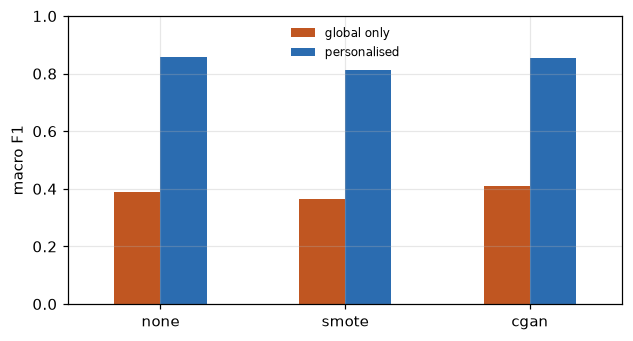

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
merged = (glob[["balance", "macro_f1"]].rename(columns={"macro_f1": "global only"})
          .merge(balance[["balance", "macro_f1"]]
                 .rename(columns={"macro_f1": "personalised"}), on="balance")
          .set_index("balance"))
merged.plot.bar(ax=ax, rot=0, color=["#c05621", "#2b6cb0"])
ax.set(ylabel="macro F1", xlabel="", ylim=(0, 1.0))
ax.legend(frameon=False, fontsize=8)

## cGAN training

The discriminator loss dropping below ln(2) = 0.693 is what shows the GAN is
learning. An earlier scaling choice left both losses pinned at that value
indefinitely — see `docs/experiments.md`.

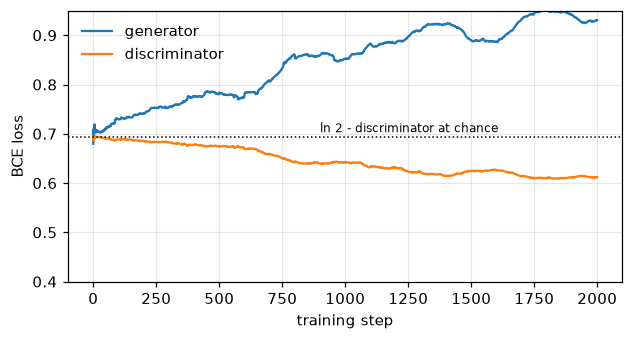

In [6]:
loss = pd.read_csv("../results/cgan_training_loss.csv")
ax = loss.rolling(200, min_periods=1).mean().plot(figsize=(6.5, 3.2), lw=1.5)
ax.axhline(np.log(2), color="k", ls=":", lw=1)
ax.text(len(loss) * 0.45, np.log(2) + 0.01, "ln 2 - discriminator at chance", fontsize=8)
ax.set(xlabel="training step", ylabel="BCE loss", ylim=(0.4, 0.95))
ax.legend(frameon=False)